In [1]:
from factor_diffusion_train import FACTOR_NAMES, PREFIX
from factor_model import FactorModel, load_model
from factor_diffusion_sample import NUM_GENERATE
import numpy as np
import os
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

/home/renyi/anaconda3/envs/diffusion_factor_model/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = load_model(PREFIX)
print(PREFIX)

model/regression


In [3]:
test = pd.read_csv(f"{PREFIX}/test_factors.csv")[FACTOR_NAMES].values

### Factor Level Evaluation

In [4]:
sampled = np.load(f"{PREFIX}/samples/factor_ddpm_{NUM_GENERATE}.npy")
sampled.shape, test.shape

((2048, 7), (1174, 7))

In [5]:
#GT = model.F
#GT = GT.drop(columns=['alpha']).values
GT = test

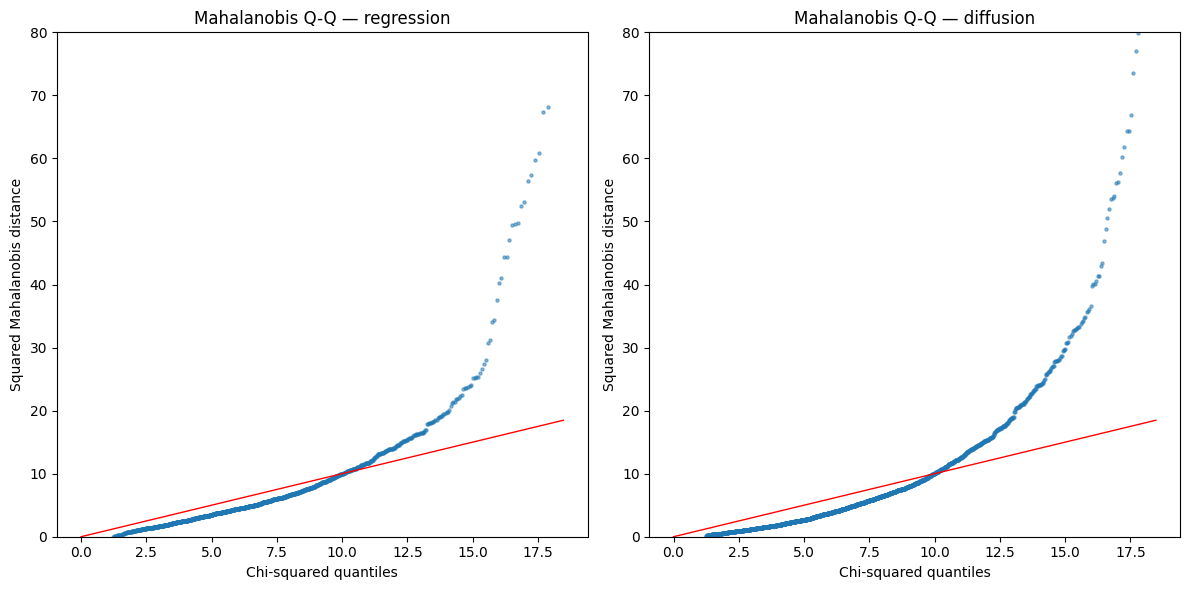

In [6]:
# 2.0 Mahalanobis check
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

axs = [(ax1, GT, "regression"),
                     (ax2, sampled, "diffusion")]
for ax, X, title in axs:
    p = X.shape[1]
    mean = X.mean(axis=0)
    cov = np.cov(X, rowvar=False)
    diff = X - mean
    d2 = (diff @ np.linalg.inv(cov) * diff).sum(axis=1)
    quantiles = stats.chi2.ppf(np.linspace(0.01, 0.99, len(d2)), df=p)
    ax.set_ylim(0, 80)
    ax.scatter(quantiles, np.sort(d2), s=5, alpha=0.5)
    ax.plot([0, quantiles.max()], [0, quantiles.max()], color="red", linewidth=1)
    ax.set_xlabel("Chi-squared quantiles")
    ax.set_ylabel("Squared Mahalanobis distance")
    ax.set_title(f"Mahalanobis Q-Q — {title}")

plt.tight_layout()
plt.show()

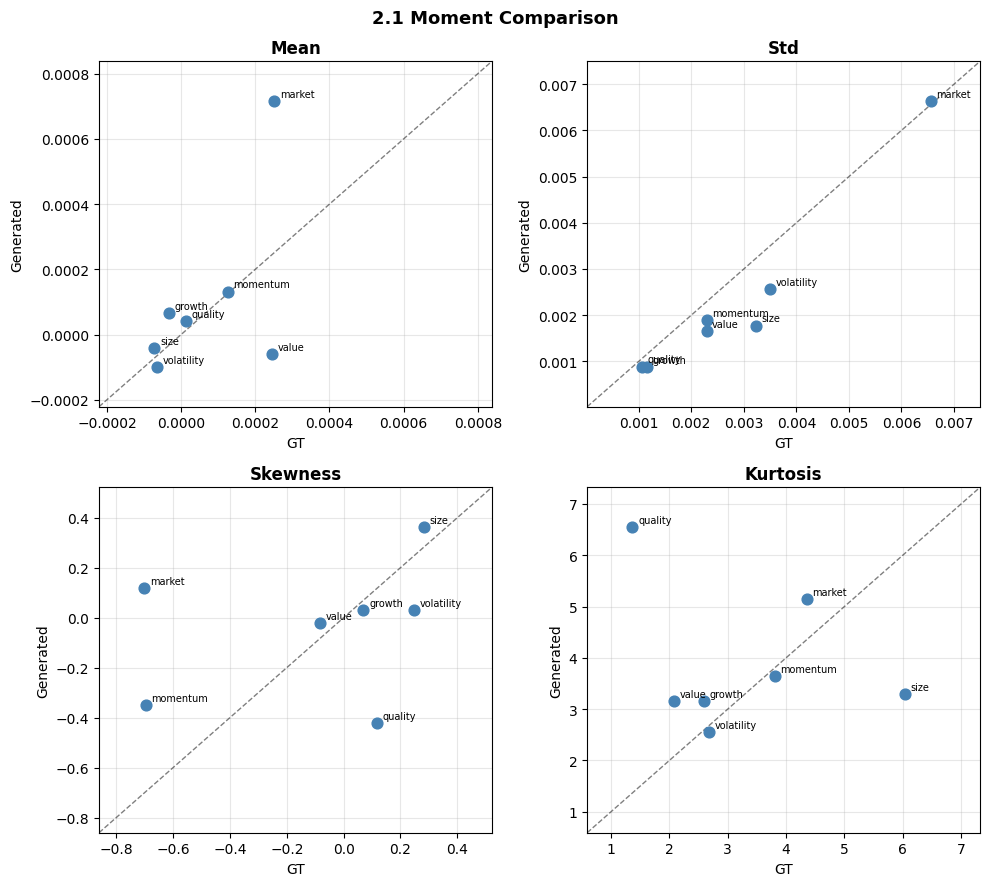

In [7]:
# 2.1 Moment Comparison
def compute_moments(data):
    return [np.mean(data, axis=0), np.std(data, axis=0),
            stats.skew(data, axis=0), stats.kurtosis(data, axis=0)]

m_gt  = compute_moments(GT)
m_gen = compute_moments(sampled)
moment_names = ['Mean', 'Std', 'Skewness', 'Kurtosis']

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, name, gt_m, gen_m in zip(axes.flatten(), moment_names, m_gt, m_gen):
    ax.scatter(gt_m, gen_m, color='steelblue', s=60, zorder=3)
    for i, fn in enumerate(FACTOR_NAMES):
        ax.annotate(fn, (gt_m[i], gen_m[i]), fontsize=7, xytext=(4, 3), textcoords='offset points')
    lim = [min(gt_m.min(), gen_m.min()), max(gt_m.max(), gen_m.max())]
    pad = (lim[1] - lim[0]) * 0.15 or 0.01
    lim = [lim[0] - pad, lim[1] + pad]
    ax.plot(lim, lim, 'k--', lw=1, alpha=0.5)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('GT'); ax.set_ylabel('Generated')
    ax.set_title(name, fontweight='bold')
    ax.grid(True, alpha=0.3)

fig.suptitle('2.1 Moment Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

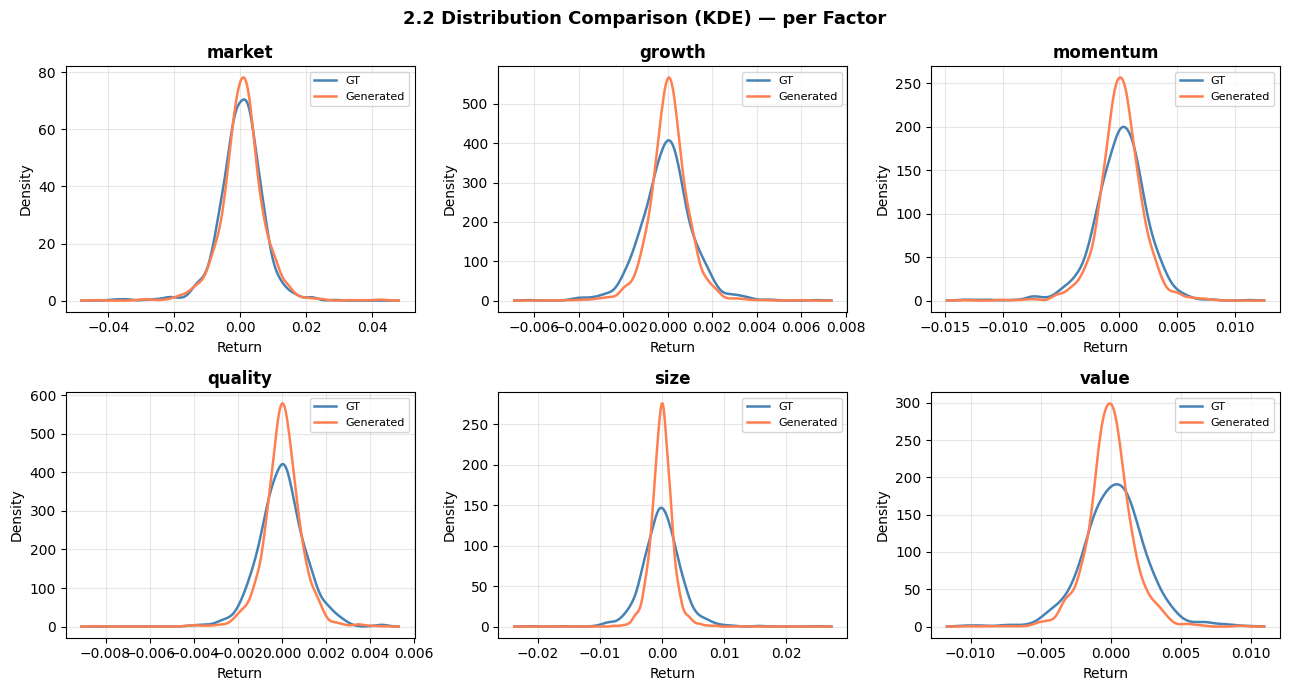

In [8]:
# 2.2 Distribution Comparison (KDE)
from scipy.stats import gaussian_kde

n_factors = len(FACTOR_NAMES)
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for ax, name, i in zip(axes.flatten(), FACTOR_NAMES, range(n_factors)):
    gt_vals  = GT[:, i]
    gen_vals = sampled[:, i]

    x_min = min(gt_vals.min(), gen_vals.min())
    x_max = max(gt_vals.max(), gen_vals.max())
    pad = (x_max - x_min) * 0.05
    x = np.linspace(x_min - pad, x_max + pad, 300)

    for vals, label, color in [(gt_vals, 'GT', 'steelblue'), (gen_vals, 'Generated', 'coral')]:
        kde = gaussian_kde(vals)
        ax.plot(x, kde(x), label=label, color=color, lw=1.8)

    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Return'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('2.2 Distribution Comparison (KDE) — per Factor', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

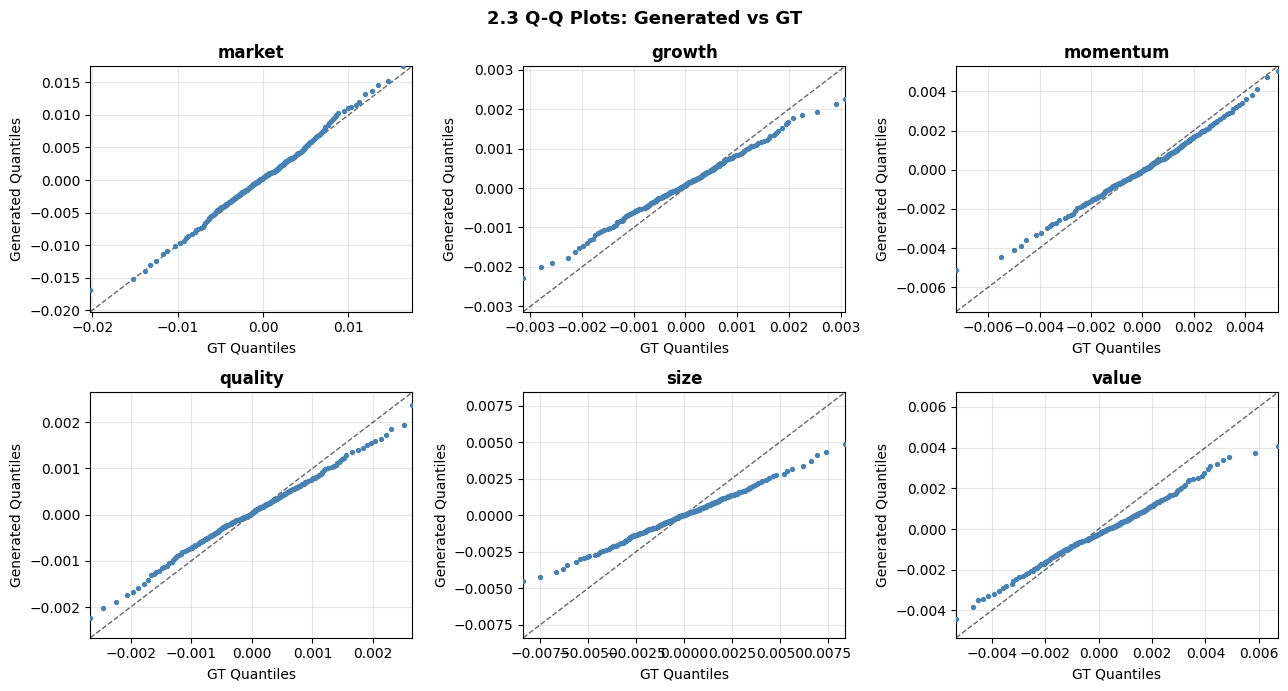

In [9]:
# 2.3 Quantile-Quantile (Q-Q) Plots
n_quantiles = 200
probs = np.linspace(0.01, 0.99, n_quantiles)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for ax, name, i in zip(axes.flatten(), FACTOR_NAMES, range(len(FACTOR_NAMES))):
    q_gt  = np.quantile(GT[:, i],      probs)
    q_gen = np.quantile(sampled[:, i], probs)

    ax.scatter(q_gt, q_gen, s=8, color='steelblue', zorder=3)

    lim = [min(q_gt.min(), q_gen.min()), max(q_gt.max(), q_gen.max())]
    ax.plot(lim, lim, 'k--', lw=1, alpha=0.6)
    ax.set_xlim(lim); ax.set_ylim(lim)

    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('GT Quantiles')
    ax.set_ylabel('Generated Quantiles')
    ax.grid(True, alpha=0.3)

fig.suptitle('2.3 Q-Q Plots: Generated vs GT', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# 2.4 Kolmogorov-Smirnov Test
# Use D statistic directly with fixed threshold (D < 0.05) instead of p-value,
# which is sample-size dependent.
from scipy.stats import ks_2samp

D_THRESHOLD = 0.05
n_eff = len(GT) * len(sampled) / (len(GT) + len(sampled))

ks_stats, ks_pvals = [], []
for i in range(len(FACTOR_NAMES)):
    stat, pval = ks_2samp(GT[:, i], sampled[:, i])
    ks_stats.append(stat)
    ks_pvals.append(pval)

print(f"Factor            KS Stat    pass (D<{D_THRESHOLD})   n_eff={n_eff:.0f}")
print("-" * 50)
for name, stat, pval in zip(FACTOR_NAMES, ks_stats, ks_pvals):
    result = "pass" if stat < D_THRESHOLD else "FAIL"
    print(f"{name:<18} {stat:.4f}     {result}")

Factor            KS Stat    pass (D<0.05)   n_eff=746
--------------------------------------------------
market             0.0405     pass
growth             0.1077     FAIL
momentum           0.0712     FAIL
quality            0.0841     FAIL
size               0.1371     FAIL
value              0.1505     FAIL
volatility         0.0887     FAIL


In [11]:
jupyter nbconvert --to webpdf evaluation.ipynb

SyntaxError: invalid syntax (2507530244.py, line 1)

### Cross-Sectional Evaluation